In [1]:
import os
import numpy as np
import random  # For generating random values for augmentation
from PIL import Image, ImageEnhance  # For image processing and enhancem
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential  # For building the model
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam  # For optimizer
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle

In [2]:
# Directories for training and testing data
train_dir = (r'E:\MRI tumor\Training')
test_dir = (r'E:\MRI tumor\Testing')

# Load and shuffle the train data
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

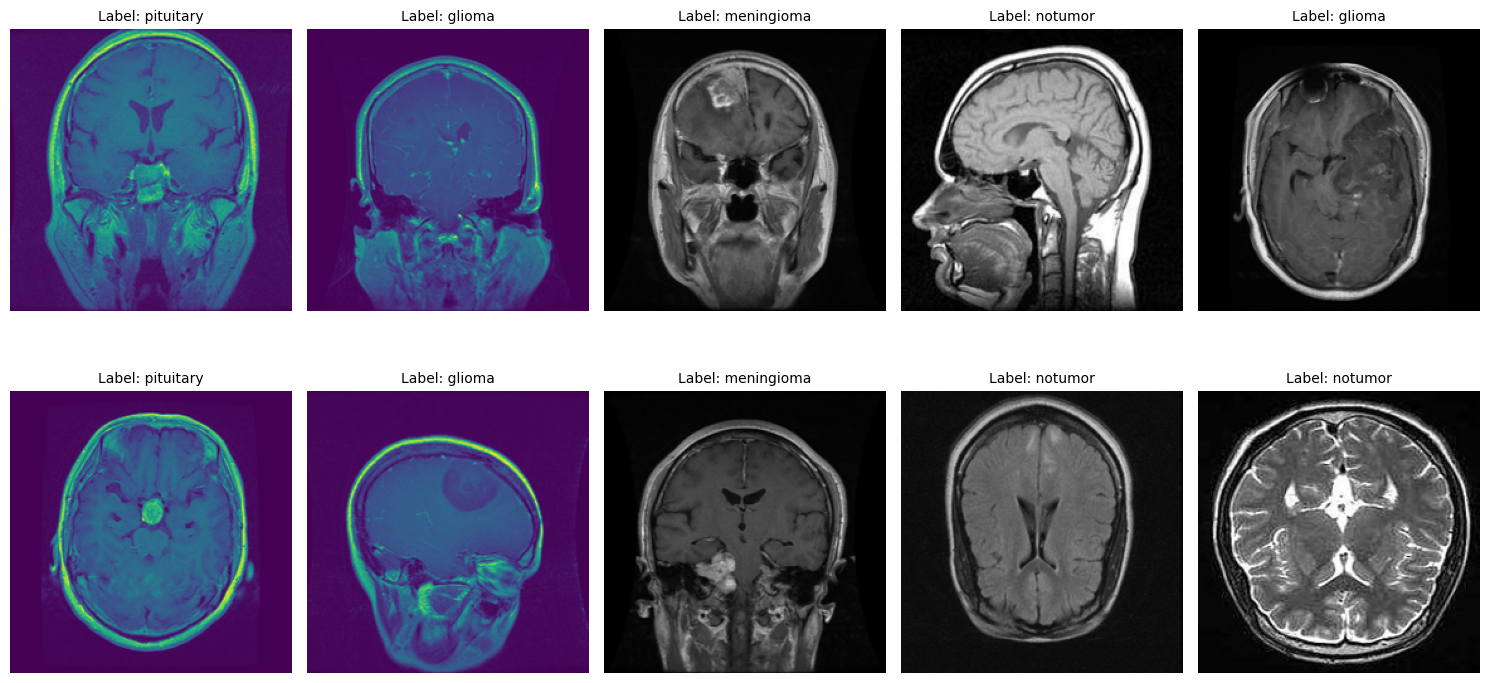

In [5]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    # Load image
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))
    # Display image
    axes[i].imshow(img)
    axes[i].axis('off') 
    # Display class label in the second row
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()

In [6]:
 #Image Augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))  # Random contrast
    image = np.array(image) / 255.0  # Normalize pixel values to [0, 1]
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
    unique_labels = os.listdir(train_dir)  # Ensure unique labels are determined
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  # Open and augment images
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  # Encode labels
            yield batch_images, batch_labels

In [7]:
# Model architecture
IMAGE_SIZE = 128  # Image size for resizing
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model)  
model.add(Flatten())
model.add(Dropout(0.3)) 
model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model.add(Dropout(0.5))
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)  # Steps per epoch
epochs = 20

# Train the model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)


Epoch 1/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 431s 2s/step - loss: 0.5668 - sparse_categorical_accuracy: 0.7845
Epoch 2/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 399s 1s/step - loss: 0.3053 - sparse_categorical_accuracy: 0.8905
Epoch 3/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 403s 1s/step - loss: 0.2075 - sparse_categorical_accuracy: 0.9261
Epoch 4/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 427s 2s/step - loss: 0.1524 - sparse_categorical_accuracy: 0.9427
Epoch 5/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 351s 1s/step - loss: 0.1259 - sparse_categorical_accuracy: 0.9532
Epoch 6/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 349s 1s/step - loss: 0.0964 - sparse_categorical_accuracy: 0.9659
Epoch 7/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 355s 1s/step - loss: 0.0693 - sparse_categorical_accuracy: 0.9762
Epoch 8/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 356s 1s/step - loss: 0.0816 - sparse_categorical_accuracy: 0.9727
Epoch 9/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 355s 1s/step - loss: 0.0510 - sparse_categorical_accuracy: 0.9820
Epoch 10/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 351s 

In [9]:
# Save the entire model
model.save("model.h5")

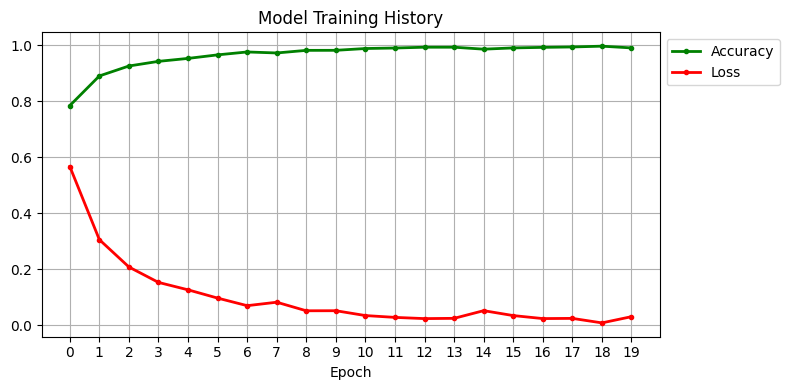

In [11]:
plt.figure(figsize=(8, 4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('Epoch')
plt.xticks(range(epochs))
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encode_label(test_labels)  

# Predict using the trained model
test_predictions  = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.76      0.85       400
           1       0.82      0.99      0.89       400
           2       0.96      1.00      0.98       400
           3       1.00      0.97      0.98       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600



Confusion Matrix:
[[303  80  17   0]
 [  4 395   0   1]
 [  0   0 400   0]
 [  5   8   0 387]]


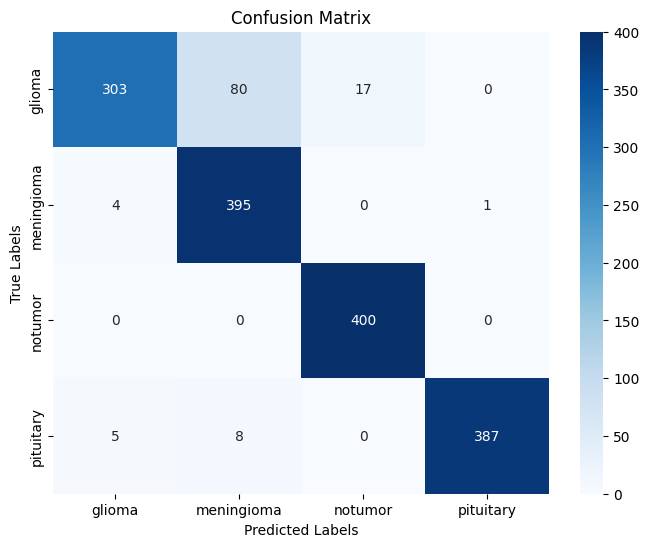

In [13]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

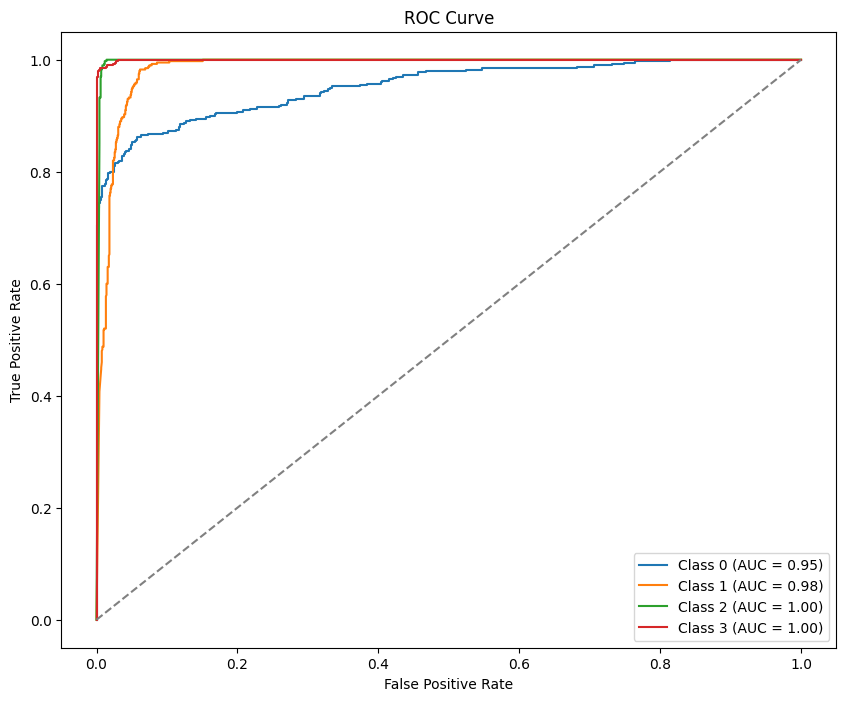

In [14]:
# 4. ROC Curve and AUC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

In [15]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Class labels
class_labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 634ms/step


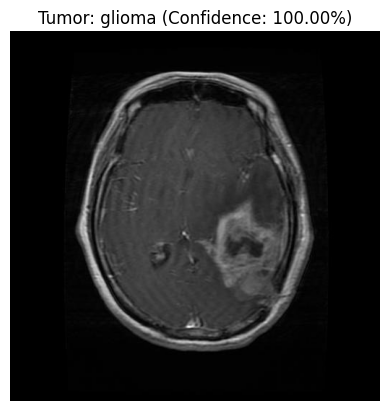

In [16]:
image_path ="E:\MRI tumor\Testing\glioma\Te-gl_12.jpg"
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


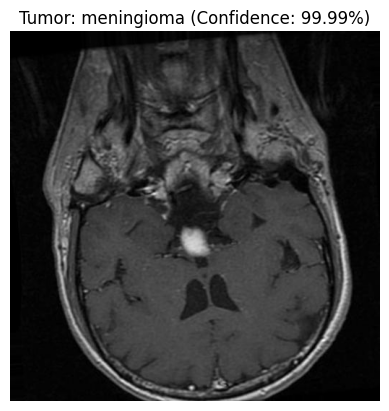

In [17]:
image_path = "E:\MRI tumor\Testing\meningioma\Te-aug-me_14.jpg" # Provide the path to your new image
detect_and_display(image_path, model) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


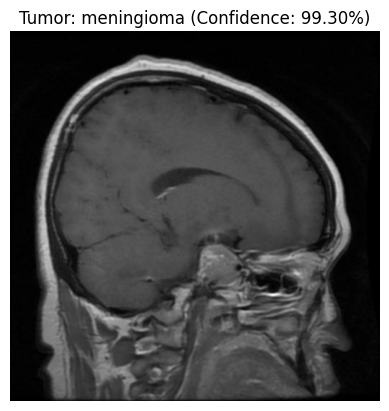

In [23]:
image_path = 'E:\MRI tumor\Testing\pituitary\Te-pi_7.jpg'  # Provide the path to your new image
detect_and_display(image_path, model) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step


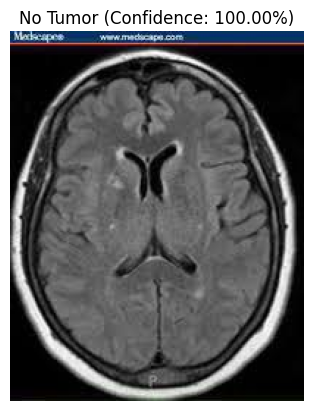

In [25]:
image_path = "E:\\MRI tumor\\Testing\\notumor\\Te-no_1.jpg" # Provide the path to your new image
detect_and_display(image_path, model) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


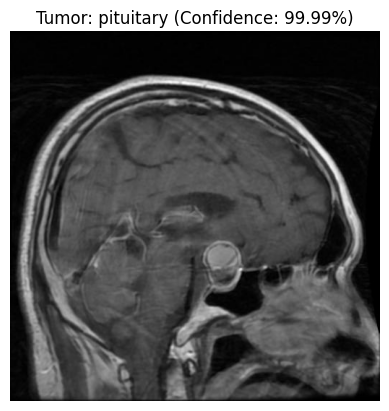

In [26]:
image_path = "E:\MRI tumor\Testing\pituitary\Te-pi_20.jpg" # Provide the path to your new image
detect_and_display(image_path, model) 